In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Best-fit m = 0.9655
Reduced chi-square = 0.0192


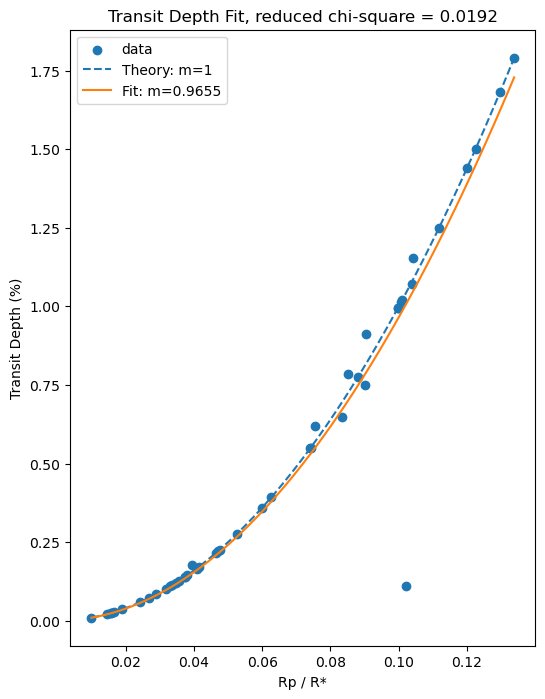

In [2]:
df = pd.read_csv("data2025.csv", comment="#") 
# Read the exoplanet data from the csv file.
# comment = "#" tells pandas to ignore lines that start with #.

small_df = df[
    (df["default_flag"] == 1)&
    (df["pl_trandep"].notna())&
    (df["pl_ratror"].notna())
].copy()
# Since each planet have multiple sets of data, I only keep the default NASA record for each planet.
# I also remove rows where transit depth or Rp/R* is missing.

x = small_df["pl_ratror"].to_numpy()
y = small_df["pl_trandep"].to_numpy()
# Define x and y for the fit, where x = planet radius / stellar radius, and y = observed transit depth in percent.

def model(x, m): 
    return m * 100 * x**2
# Define the model: transit depth (%) = m * 100 * (Rp/R*)**2

popt, pcov = curve_fit(model, x, y, p0=[1])
m_fit = popt[0]
# Fit the model to the data.
# Start with the inital guess of 1 for m

print(f"Best-fit m = {m_fit:.4f}") 
# Print the best-fit value of m

y_fit = model(x, m_fit) # calculate the fitted y_values from the model
residuals = y - y_fit # calculate the residuals
chi2 = np.sum(residuals**2) # calculate the simplified chi-square value
dof = len(x) - 1 # calculate the degrees of freedom (minus 1 here because there is only one fitted parameter: m)
chi2_reduced = chi2 / dof # calculate the reduced chi-square

print(f"Reduced chi-square = {chi2_reduced:.4f}")
# Print the reduced chi-square value

x_line = np.linspace(x.min(), x.max(), 500)
# Create x-values for plotting the theory and fit curves

plt.figure(figsize=(6,8)) # make the plot
plt.scatter(x, y, label="data") # plot the observed data as a scatter plot
plt.plot(x_line, model(x_line, 1), "--", label="Theory: m=1") # plot the theory curve with m = 1
plt.plot(x_line, model(x_line, m_fit), label=f"Fit: m={m_fit:.4f}") # plot the best-fit curve with fitted m value

plt.title(f"Transit Depth Fit, reduced chi-square = {chi2_reduced:.4f}")
plt.xlabel("Rp / R*")
plt.ylabel("Transit Depth (%)")
# Label the title and axes

plt.legend()
plt.show()
# Show the legend and plot

Notice that reduce chi-square is smaller than 1. I guess I set the sigma to 1 in calculating the chi-square, but the actual sigma is smaller than 1. As a result, I use the regular chi-square formula to account for the error in transit depth below.

In [3]:
sigma_y = np.abs(small_df["pl_trandeperr1"].to_numpy())
# Use the transit depth uncertainty as the y-error
# np.abs() makes sure the errors are positive

chi2_standard = np.sum((residuals / sigma_y)**2) # use the standard chi-square formula
dof = len(x) - 1 # calculate the degree of freedom
chi2_reduced_standard = chi2_standard / dof # calculate the reduced chi-square with the standard chi-square

print(f"Reduced chi-square with y-error = {chi2_reduced_standard:.4f}")

Reduced chi-square with y-error = nan


The value of reduced chi-square with y-error is undefined. It's probably because sigma_y is zero or NaN somewhere in the data.

In [4]:
bad = ~np.isfinite((residuals / sigma_y)**2) # find rows where (residuals / sigma)^2 is not a finite number
print(small_df.loc[bad, ["pl_name", "pl_trandep", "pl_ratror", "pl_trandeperr1"]]) # print the planets that cause problems in the standard chi-square calculation

        pl_name  pl_trandep  pl_ratror  pl_trandeperr1
731  TOI-4504 b      0.0718     0.0268             NaN


Best-fit m = 0.9655
Reduced chi-square with y-error = 18253.5527


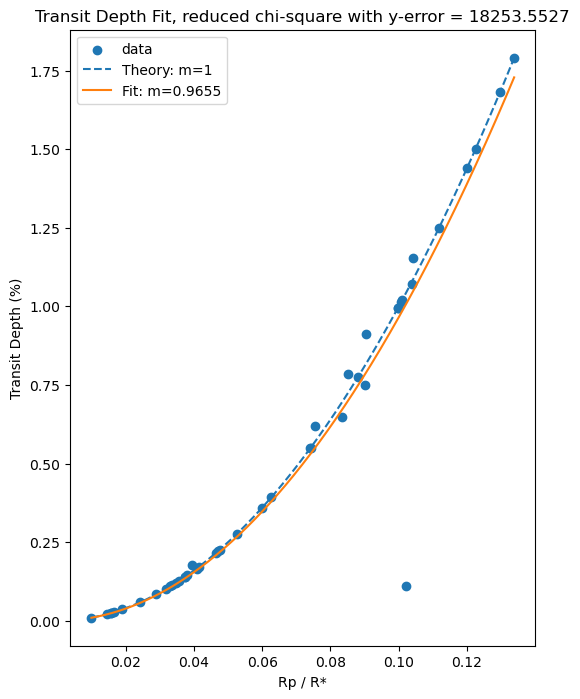

In [5]:
# rewrite the code with two modifications
# 1. redefine small_df 
# 2. use the standard formula for calculating chi-square
small_df = df[
    (df["default_flag"] == 1)&
    (df["pl_trandep"].notna())&
    (df["pl_ratror"].notna())&
    (df["pl_trandeperr1"].notna()) # remove data where the error in transit depth is NaN
].copy()

x = small_df["pl_ratror"].to_numpy()
y = small_df["pl_trandep"].to_numpy()
sigma_y = np.abs(small_df["pl_trandeperr1"].to_numpy())

def model(x, m): 
    return m * 100 * x**2

popt, pcov = curve_fit(model, x, y, p0=[1])
m_fit = popt[0]

print(f"Best-fit m = {m_fit:.4f}") 

y_fit = model(x, m_fit)
residuals = y - y_fit
chi2_standard = np.sum((residuals / sigma_y)**2) # use the standard equation of chi2
dof = len(x) - 1
chi2_reduced_standard = chi2_standard / dof

print(f"Reduced chi-square with y-error = {chi2_reduced_standard:.4f}")

x_line = np.linspace(x.min(), x.max(), 500)

plt.figure(figsize=(6,8))
plt.scatter(x, y, label="data")
plt.plot(x_line, model(x_line, 1), "--", label="Theory: m=1") 
plt.plot(x_line, model(x_line, m_fit), label=f"Fit: m={m_fit:.4f}")

plt.title(f"Transit Depth Fit, reduced chi-square with y-error = {chi2_reduced_standard:.4f}")
plt.xlabel("Rp / R*")
plt.ylabel("Transit Depth (%)")

plt.legend()
plt.show()

Reduced chi-square is large this time, meaning that the errors are too small

Transit depth bin counts:
0-0.25% 23
0.25-0.5% 3
0.5-0.75% 4
0.75-1% 6
1-1.25% 5
1.25-1.5% 1
1.5-1.75% 2
1.75-2% 1
2-10% 0


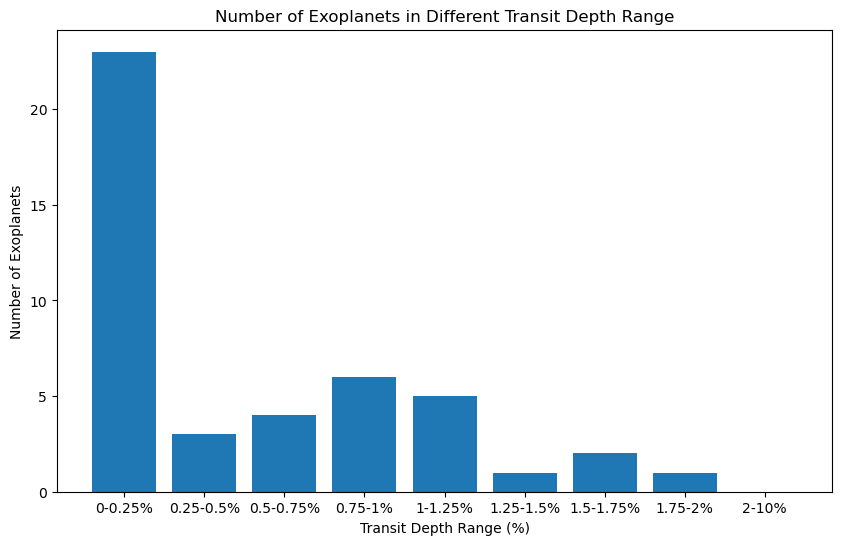

In [13]:
# Here I draw a bar chart to show the distribution of transit depth

lowers = [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
uppers = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 10]
# Define each range.

labels = []
counts = []
# Create empty lists to store the labels for each bin and the number of exoplanets in each bin.

for i in range(len(lowers)):
    low = lowers[i]
    high = uppers[i]
    
    count = len(
     small_df[
        (small_df["pl_trandep"]>= low)&
        (small_df["pl_trandep"]< high)
    ])
    # Count how many planets are in the current bin
    
    labels.append(f"{low}-{high}%")
    counts.append(count)
# Loop through each transit depth range and append the corresponding range and number to the list. 
    
print("Transit depth bin counts:")
for i in range(len(labels)):
    print(labels[i], counts[i])
# Print the number of planets in each transit depth bin.
    
plt.figure(figsize=(10,6))
plt.bar(labels, counts)
plt.title("Number of Exoplanets in Different Transit Depth Range")
plt.xlabel("Transit Depth Range (%)")
plt.ylabel("Number of Exoplanets")
plt.show()
# Plot the counts as bar chart